# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

## 🎯 Antes de empezar: regresión vs clasificación

En el notebook anterior hicimos **clasificación**: el modelo predecía a qué CATEGORÍA pertenecía una imagen (10 clases discretas).

En este notebook hacemos **regresión**: el modelo predice un VALOR CONTINUO (un número real). En este caso, las millas por galón (MPG) que consume un coche.

### Diferencias clave que veremos en el código

| Aspecto | Clasificación (anterior) | Regresión (este) |
|---------|--------------------------|------------------|
| Capa de salida | `Dense(10, softmax)` | `Dense(1)` (sin activación) |
| Loss | `sparse_categorical_crossentropy` | `mse` (mean squared error) |
| Métricas | `accuracy` | `mae`, `mse` |
| Salida | vector de probabilidades | un único número real |

### Intuición de la pérdida MSE
**MSE (Mean Squared Error)** = media de los errores al cuadrado:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

*Ejemplo numérico*: si las predicciones son `[10, 12, 9]` y los reales son `[11, 10, 9]`, los errores son `[-1, 2, 0]`, los cuadrados `[1, 4, 0]`, y MSE = (1+4+0)/3 = 1.67.

In [1]:
# Importamos las librerías habituales para análisis numérico, datos tabulares y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos keras desde tensorflow para construir la red neuronal de regresión
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

### 📥 ¿Qué hace `keras.utils.get_file`?
Es una utilidad que descarga un archivo de internet a una carpeta local de caché y devuelve la **ruta local** al archivo descargado. La próxima vez que se llame, no descarga otra vez (mira la caché).

In [2]:
# Descargamos el archivo de datos. La URL original del UCI a veces da error 403,
# así que probamos varias fuentes en orden hasta que una funcione.
urls_a_probar = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data",
    "https://storage.googleapis.com/tensorflow/tf-keras-datasets/auto-mpg.data",
]

dataset_path = None
for url in urls_a_probar:
    try:
        # get_file descarga el archivo y devuelve la ruta local. Si la URL falla, lanza una excepción
        dataset_path = keras.utils.get_file("auto-mpg.data", url)
        print(f"Descargado correctamente desde: {url}")
        break
    except Exception as e:
        print(f"No funcionó {url}: {e}")

# Si ninguna funcionó, usamos seaborn como último recurso
if dataset_path is None:
    print("\nLas URLs fallan. Cargamos el dataset desde seaborn como alternativa.")
    raw_dataset = sns.load_dataset('mpg')
    # Renombramos las columnas para que coincidan con el ejercicio
    raw_dataset = raw_dataset.rename(columns={
        'mpg': 'MPG', 'cylinders': 'Cylinders', 'displacement': 'Displacement',
        'horsepower': 'Horsepower', 'weight': 'Weight', 'acceleration': 'Acceleration',
        'model_year': 'Model Year', 'origin': 'Origin', 'name': 'Car name'
    })
    # En seaborn Origin ya está como string ('usa'/'europe'/'japan'). Lo convertimos a 1/2/3 para coherencia
    raw_dataset['Origin'] = raw_dataset['Origin'].map({'usa': 1, 'europe': 2, 'japan': 3})
else:
    print(f"\nRuta local del archivo: {dataset_path}")

Descargado correctamente desde: https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data

Ruta local del archivo: /Users/andoni/.keras/datasets/auto-mpg.data


Importelo usando pandas.

### 📄 Cómo leer el archivo con pandas
El archivo no tiene cabecera (`header`), las columnas están separadas por **espacios en blanco múltiples** (no por comas), y los valores faltantes están marcados con `?`.

Por eso pasamos:
- `names=column_names` → para definir nosotros los nombres de columna.
- `na_values='?'` → para que pandas convierta los `?` en `NaN`.
- `sep=r'\s+'` → separador = uno o más espacios.
- `skipinitialspace=True` → ignora espacios al principio de cada campo.

In [3]:
# Definimos los nombres de las columnas tal como los proporciona el ejercicio
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [4]:
# Si descargamos por URL, leemos con pandas. Si fue por seaborn, raw_dataset ya está cargado
if dataset_path is not None:
    # Leemos el archivo con pandas. Como el formato es algo peculiar, le pasamos varios parámetros:
    # - names: definimos los nombres de columna porque el archivo no tiene cabecera
    # - na_values='?': convertimos los signos de interrogación en valores faltantes (NaN)
    # - comment='\t': ignoramos cualquier cosa después de un tabulador (los nombres de coche llevan tabuladores delante)
    # - sep=r'\s+': separador = uno o más espacios en blanco
    # - skipinitialspace=True: ignoramos espacios al inicio de cada celda
    raw_dataset = pd.read_csv(
        dataset_path,
        names=column_names,
        na_values='?',
        comment='\t',
        sep=r'\s+',
        skipinitialspace=True
    )

# Hacemos una copia para trabajar sobre ella sin tocar el original
dataset = raw_dataset.copy()

# Echamos un primer vistazo a las últimas filas
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.0,2720.0,19.4,82,1,chevy s-10


### Limpia los datos

Trata los missings y variables categóricas

### 🧹 Pasos de limpieza que vamos a hacer

**1. Missings (valores faltantes)**
- *Intuición*: si una fila tiene un valor desconocido en alguna columna, la red no sabe qué hacer con un NaN. Tenemos dos opciones: rellenar (imputar) o eliminar la fila. Como el dataset tiene pocas filas con NaN, las eliminamos sin más.
- *Comprobación previa*: usamos `.isna().sum()` para ver cuántos NaN hay en cada columna.

**2. Variable categórica `Origin`**
- *Origin* contiene valores 1, 2, 3 que representan: 1=USA, 2=Europa, 3=Japón.
- *El problema*: aunque son números, NO tienen sentido aritmético. "Japón (3)" no es "USA (1) × 3". Si dejásemos esos números, la red podría inventarse relaciones falsas ("a más origin, más MPG"), cuando en realidad son etiquetas.
- *Solución: one-hot encoding*. Creamos tres columnas binarias (`USA`, `Europe`, `Japan`) que valen 1 si el coche es de ese origen y 0 si no. Así no hay orden artificial entre categorías.
- *Ejemplo*: un coche con Origin=2 pasa a tener `USA=0, Europe=1, Japan=0`.

**3. Columna `Car name`**
- Es texto libre con el modelo del coche (ej: "chevrolet chevelle malibu"). Tiene cientos de valores distintos y no es informativo para predecir MPG sin un tratamiento NLP. La eliminamos.

In [5]:
# Vemos cuántos missings hay por columna ANTES de limpiar
print("Missings por columna:")
print(dataset.isna().sum())

Missings por columna:
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car name        0
dtype: int64


In [6]:
# Eliminamos las filas que tengan algún NaN. dropna() devuelve un nuevo DataFrame sin esas filas
dataset = dataset.dropna()

# Quitamos también la columna 'Car name' porque es texto libre con muchos valores únicos y no aporta
dataset = dataset.drop('Car name', axis=1)

# Comprobamos cuántas filas nos quedan
print(f"Forma del dataset tras limpiar: {dataset.shape}")

Forma del dataset tras limpiar: (392, 8)


In [7]:
# Tratamos la variable categórica 'Origin' con one-hot encoding.
# Primero mapeamos los códigos numéricos a nombres legibles, así las nuevas columnas tendrán nombres claros
origin = dataset.pop('Origin')   # extraemos la columna y la quitamos del DataFrame

# Creamos tres columnas binarias: cada una vale 1 si el coche es de ese origen
dataset['USA']    = (origin == 1) * 1.0
dataset['Europe'] = (origin == 2) * 1.0
dataset['Japan']  = (origin == 3) * 1.0

# Comprobamos cómo queda el DataFrame con las nuevas columnas dummy
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,1.0,0.0,0.0


### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

### ✂️ Cómo dividimos: `sample` + `drop`
- `dataset.sample(frac=0.8, random_state=0)` toma una muestra aleatoria del 80% de las filas. El `random_state=0` fija la semilla para que el resultado sea reproducible (cada vez que ejecutemos saldrá el mismo split).
- `dataset.drop(train_dataset.index)` toma las filas que NO fueron al train (el 20% restante).

In [8]:
# Tomamos el 80% de las filas al azar para entrenamiento. random_state=0 fija la aleatoriedad
train_dataset = dataset.sample(frac=0.8, random_state=0)

# El test es lo que NO está en train: usamos drop() pasando los índices del train para quedarnos con el resto
test_dataset = dataset.drop(train_dataset.index)

print(f"Filas en train: {len(train_dataset)}")
print(f"Filas en test:  {len(test_dataset)}")

Filas en train: 314
Filas en test:  78


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

### 📊 ¿Qué es un *pairplot*?
`sns.pairplot(df)` dibuja una rejilla cuadrada donde:
- En la **diagonal** hay un histograma de cada variable (su distribución).
- **Fuera de la diagonal** hay un scatter plot de cada par de variables.

Sirve para detectar relaciones lineales, curvas, agrupamientos y outliers de un vistazo.

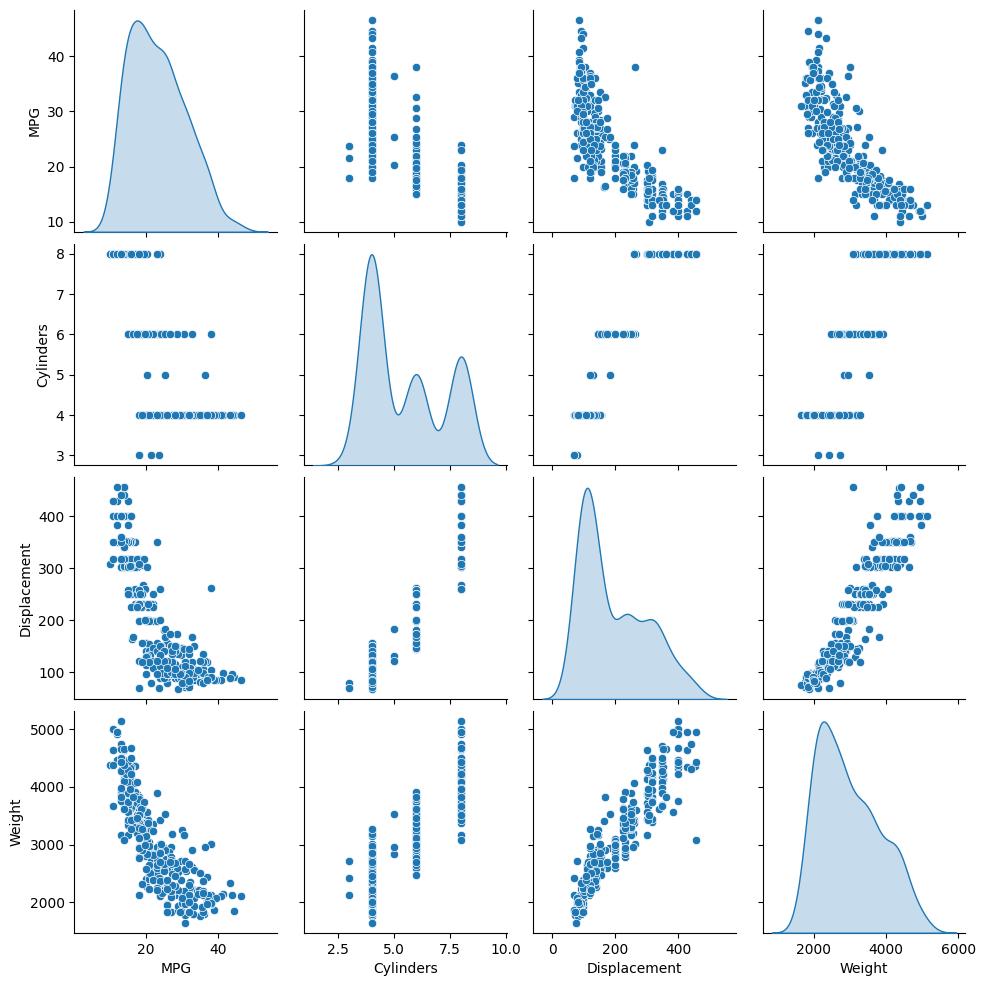

In [9]:
# Hacemos un pairplot solo de unas pocas variables para que sea legible (con todas saldría enorme).
# diag_kind='kde' usa una curva suavizada en la diagonal en lugar de barras de histograma
sns.pairplot(
    train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']],
    diag_kind='kde'
)
plt.show()

Tambien revise las estadisticas generales:

### 📈 `.describe()`
Devuelve, para cada columna numérica, los estadísticos básicos: count, media, desv. estándar, min, cuartiles (25%, 50%, 75%) y max.

Sirve para detectar:
- Escalas muy distintas entre variables (Weight en miles, MPG en decenas, Cylinders en unidades pequeñas) → motivo para estandarizar.
- Outliers (max muy alejado del 75%).
- Variables con desviación estándar 0 (constantes, no aportan información).

In [10]:
# Pedimos estadísticos descriptivos del train. Lo trasponemos con .T para verlo más cómodo
# (cada variable en una fila en lugar de en una columna)
train_stats = train_dataset.describe()

# Quitamos la fila MPG porque es nuestra variable objetivo, no una feature
train_stats.pop('MPG')

# Trasponemos para que cada variable sea una fila
train_stats = train_stats.transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0


### Separa las features del target

Separe el target de las features.

### 🎯 ¿Por qué separamos features y target?
El modelo aprende a predecir y (target) **a partir de** X (features). Si dejásemos MPG dentro de X durante el entrenamiento, el modelo "haría trampa" copiando el valor real.

**Truco con `pop`**: `train_dataset.pop('MPG')` hace dos cosas a la vez:
1. Devuelve la columna MPG (que guardamos en `train_labels`).
2. La elimina del DataFrame original (así `train_dataset` se queda solo con las features).

In [11]:
# Extraemos la columna MPG de cada conjunto. pop() la devuelve y la quita del DataFrame en un solo paso
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')

# Comprobamos las dimensiones: las features ya no contienen MPG
print(f"Features train: {train_dataset.shape}, Target train: {train_labels.shape}")
print(f"Features test:  {test_dataset.shape}, Target test:  {test_labels.shape}")

Features train: (314, 9), Target train: (314,)
Features test:  (78, 9), Target test:  (78,)


### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

### 📏 Estandarización (z-score)

**Intuición**: si tenemos una variable Weight con valores entre 1500 y 5000, y otra Acceleration entre 8 y 25, la red "oirá más fuerte" a la primera solo por su escala. Para que todas las variables compitan en igualdad, las llevamos a una escala común.

**Definición**: la estandarización transforma cada variable para que tenga **media 0 y desviación estándar 1**:

$$x' = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar (ambas calculadas en el TRAIN).

**Ejemplo numérico**: si Weight tiene media 2950 y desv. estándar 850, un coche con Weight=3800 pasa a $(3800-2950)/850 = 1.0$. Está 1 desviación estándar por encima de la media.

**Regla de oro: usar siempre las estadísticas del TRAIN para estandarizar también el TEST**. Si calculásemos μ y σ con todo (train+test), estaríamos filtrando información del test al entrenamiento (*data leakage*).

In [12]:
# Definimos una función auxiliar que estandariza un DataFrame usando las estadísticas del train.
# Importante: usamos train_stats['mean'] y train_stats['std'] tanto para train como para test
def norm(x):
    # Restamos la media y dividimos por la desviación estándar (z-score)
    return (x - train_stats['mean']) / train_stats['std']

# Aplicamos la función a las features de train y test
normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)

# Comprobamos que la media de cada columna en el train normalizado es cercana a 0
print("Media tras estandarizar (train, debería ser ~0):")
print(normed_train_data.mean().round(3))

Media tras estandarizar (train, debería ser ~0):
Cylinders       0.0
Displacement    0.0
Horsepower     -0.0
Weight         -0.0
Acceleration   -0.0
Model Year      0.0
USA             0.0
Europe          0.0
Japan           0.0
dtype: float64


Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

### 🏗️ Anatomía del modelo de regresión

**Capa 1 — `Dense(64, activation='relu', input_shape=[n_features])`**
- 64 neuronas con activación ReLU. `input_shape` solo se especifica en la primera capa: indica cuántas features tiene cada muestra.

**Capa 2 — `Dense(64, activation='relu')`**
- Otra capa oculta de 64 neuronas con ReLU. Da capacidad para aprender relaciones no lineales entre las features.

**Capa 3 — `Dense(1)`**
- *Una sola neurona, sin activación*. Esta es la GRAN diferencia respecto a clasificación: queremos un número real cualquiera (positivo, negativo, decimal). Si pusiéramos softmax o sigmoid limitaríamos el rango de salida.

### Diferencias con la compilación de clasificación

**Optimizer: `RMSprop(0.001)`**
- *Intuición*: igual que Adam, ajusta los pesos para minimizar la loss, pero con una técnica que escala el paso de cada parámetro según el historial reciente de gradientes. El número 0.001 es la **learning rate** (el tamaño del paso).
- *Ejemplo*: una learning rate de 0.001 significa que en cada actualización los pesos se mueven una milésima parte del gradiente. Demasiado grande = saltarse el mínimo; demasiado pequeño = entrenar es lento.

**Loss: `mse` (mean squared error)**
- Estándar en regresión. Penaliza más fuertemente los errores grandes (porque eleva al cuadrado).

**Metrics: `['mae', 'mse']`**
- *MAE (Mean Absolute Error)*: media de los errores en valor absoluto. Más interpretable porque está en las MISMAS unidades que el target. Si MAE=2, en promedio nos equivocamos en 2 MPG.
- *MSE*: misma idea pero con cuadrados, en unidades².

In [13]:
# Importamos el optimizador RMSprop, que es el que pide el ejercicio
from tensorflow.keras.optimizers import RMSprop

# Definimos una función que construye el modelo. Lo hacemos como función para poder reentrenar fácil
def build_model():
    model = keras.Sequential([
        # Primera capa oculta: 64 neuronas con ReLU. input_shape le dice a la red cuántas features tiene cada muestra
        keras.layers.Dense(64, activation='relu', input_shape=[len(normed_train_data.keys())]),
        
        # Segunda capa oculta: otras 64 neuronas con ReLU para capturar no-linealidades
        keras.layers.Dense(64, activation='relu'),
        
        # Capa de salida: UNA neurona SIN activación, porque queremos predecir un valor continuo cualquiera (MPG)
        keras.layers.Dense(1)
    ])
    
    # Compilamos: optimizer RMSprop con learning rate 0.001, loss MSE, métricas MAE y MSE
    model.compile(
        loss='mse',
        optimizer=RMSprop(0.001),
        metrics=['mae', 'mse']
    )
    return model

# Llamamos a la función para crear el modelo
model = build_model()

/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-06 10:46:26.324953: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-06 10:46:26.324986: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-06 10:46:26.324989: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-06 10:46:26.325005: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-06 10:46:26.325015: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fac

### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

### 📋 Cómo leer el `summary()`
Para cada capa nos dice:
- **Layer (type)**: nombre y tipo.
- **Output Shape**: la forma del tensor que sale de esa capa.
- **Param #**: cuántos parámetros entrenables tiene esa capa (pesos + biases).

**Cálculo de parámetros de una `Dense`**: si la capa anterior tiene N neuronas y la actual M, hay $N \times M$ pesos + $M$ biases = $M(N+1)$ parámetros.

*Ejemplo*: si tenemos 9 features de entrada y la primera Dense tiene 64 neuronas → $64 \times (9+1) = 640$ parámetros.

In [14]:
# Imprimimos el resumen del modelo: capas, output shape y número de parámetros entrenables
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

### 🔁 ¿Qué es `validation_split`?
Es un parámetro de `fit()` que separa AUTOMÁTICAMENTE una fracción del train para usarla como **validación durante el entrenamiento** (no se usa para ajustar pesos, solo para vigilar).

**Diferencia importante con el conjunto de test**:
- *Validación*: nos sirve para detectar sobreajuste DURANTE el entrenamiento y decidir hiperparámetros.
- *Test*: lo usamos al final del todo, una sola vez, para reportar cómo de bien generaliza el modelo final.

Con `validation_split=0.2`, keras coge el 20% final del train, lo aparta y, después de cada epoch, calcula la loss y métricas en ese 20%. Veremos en `history` tanto `loss` como `val_loss`, `mae` como `val_mae`, etc.

In [15]:
# Con 1000 epochs este dataset pequeño (~300 muestras) tarda >20 min y sobreajusta.
# Usamos 200 epochs + EarlyStopping: para automáticamente cuando la val_loss
# no mejora durante 20 epochs seguidos. En la práctica suele parar antes de 200.
# verbose=1 muestra el progreso en tiempo real para que veas que avanza.
EPOCHS = 1000

# EarlyStopping: si val_loss no mejora en 20 epochs seguidos, para el entrenamiento
# restore_best_weights=True recupera los pesos del mejor epoch al terminar
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    normed_train_data,
    train_labels,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Imprimimos el último epoch para ver cómo terminó el entrenamiento
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

Epoch 1/1000


2026-05-06 10:46:26.804733: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 585.3057 - mae: 23.0336 - mse: 585.3057 - val_loss: 600.1624 - val_mae: 23.5124 - val_mse: 600.1624
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 562.4726 - mae: 22.7975 - mse: 562.4726 - val_loss: 579.5369 - val_mae: 23.2827 - val_mse: 579.5369
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 543.7557 - mae: 22.5510 - mse: 543.7557 - val_loss: 558.3933 - val_mae: 23.0336 - val_mse: 558.3933
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 527.1469 - mae: 22.3693 - mse: 527.1469 - val_loss: 541.2729 - val_mae: 22.7824 - val_mse: 541.2729
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 510.5660 - mae: 22.0936 - mse: 510.5660 - val_loss: 523.4975 - val_mae: 22.4997 - val_mse: 523.4975
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 496.9704 - mae: 21.8570 - mse: 496.9704 - val_loss: 509.8441 - val_mae: 22.2191 - val_mse: 509.8441
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 48

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
165,16.424229,3.111911,16.424229,49.282326,5.808703,49.282326,165
166,49.649384,5.759983,49.649384,20.694630,3.449780,20.694630,166
167,40.661053,4.908960,40.661053,63.954777,6.466195,63.954777,167
168,27.650749,4.135666,27.650749,23.086197,3.800076,23.086197,168
169,30.607269,4.384981,30.607269,31.576048,4.509197,31.576048,169


Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

### 📈 ¿Qué buscamos en estos gráficos?
- **Si train_error y val_error bajan juntos** y se estabilizan → buena señal, el modelo está aprendiendo y generalizando.
- **Si train_error sigue bajando pero val_error empieza a SUBIR** → sobreajuste: el modelo memoriza el train pero pierde capacidad de generalizar. La epoch en la que val_error toca su mínimo es la "parada óptima" (lo que automatiza el `EarlyStopping`).

Vamos a graficar tanto MAE como MSE en el train y la validación.

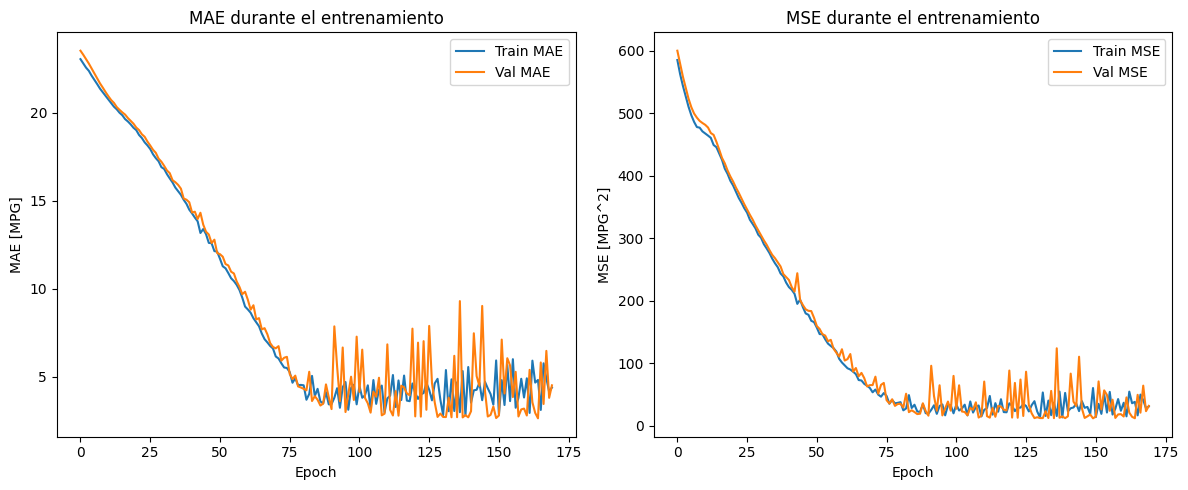

In [16]:
# Definimos una función para dibujar el progreso del entrenamiento de forma reutilizable
def plot_history(history):
    # Convertimos el diccionario history.history en un DataFrame para manipularlo cómodamente
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch
    
    # Primer gráfico: MAE en train y validación a lo largo de los epochs
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('MAE [MPG]')
    plt.plot(hist['epoch'], hist['mae'], label='Train MAE')
    plt.plot(hist['epoch'], hist['val_mae'], label='Val MAE')
    plt.legend()
    plt.title('MAE durante el entrenamiento')
    
    # Segundo gráfico: MSE en train y validación
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('MSE [MPG^2]')
    plt.plot(hist['epoch'], hist['mse'], label='Train MSE')
    plt.plot(hist['epoch'], hist['val_mse'], label='Val MSE')
    plt.legend()
    plt.title('MSE durante el entrenamiento')
    
    plt.tight_layout()
    plt.show()

# Llamamos a la función con el history del entrenamiento
plot_history(history)

¿Alguna conclusión respecto a este gráfico?

### 🧐 Lectura del gráfico

Mirando las curvas, lo más probable es que veamos un patrón de **sobreajuste** después de un cierto número de epochs:

- En los primeros epochs (digamos hasta el 100-200) tanto `train_mae` como `val_mae` bajan rápido: el modelo está aprendiendo de verdad.
- A partir de cierto punto, `train_mae` sigue bajando lentamente (el modelo memoriza más detalles del train) pero `val_mae` se estanca o empieza a subir: el modelo deja de generalizar y empieza a memorizar.

**¿Qué se hace en la práctica?** Usar `EarlyStopping`, un *callback* de keras que detiene el entrenamiento cuando la val_loss deja de mejorar durante N epochs. No lo pide este ejercicio, pero conviene saberlo:
```python
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
model.fit(..., callbacks=[early_stop])
```

Conclusión rigurosa para este caso: 1000 epochs es excesivo para un dataset tan pequeño (≈300 muestras de train). El modelo entra en sobreajuste mucho antes.

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [17]:
# Evaluamos el modelo con el conjunto de TEST normalizado.
# Devuelve la loss y las métricas que pusimos en compile (mae y mse), en ese orden.
loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=2)

print(f"\nTest MAE: {mae:.2f} MPG")    # error medio absoluto en MPG
print(f"Test MSE: {mse:.2f} MPG^2")    # error cuadrático medio
print(f"\nInterpretación: en promedio nos equivocamos en ±{mae:.2f} millas por galón al predecir")

3/3 - 0s - 17ms/step - loss: 11.1801 - mae: 2.3485 - mse: 11.1801

Test MAE: 2.35 MPG
Test MSE: 11.18 MPG^2

Interpretación: en promedio nos equivocamos en ±2.35 millas por galón al predecir


Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [18]:
# Cogemos los 10 primeros ejemplos del conjunto de test (ya normalizados)
ejemplos = normed_test_data[:10]

# Pedimos al modelo que prediga el MPG para esos 10 ejemplos
predicciones_10 = model.predict(ejemplos)

# Mostramos predicción vs valor real para comparar visualmente
comparacion = pd.DataFrame({
    'Real (MPG)': test_labels[:10].values,
    'Predicho (MPG)': predicciones_10.flatten().round(2),
    'Error': (test_labels[:10].values - predicciones_10.flatten()).round(2)
})
comparacion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


,Real (MPG),Predicho (MPG),Error
0,15.0,11.400000,3.60
1,10.0,10.220000,-0.22
2,9.0,11.120000,-2.12
3,25.0,25.030001,-0.03
4,19.0,19.610001,-0.61
5,14.0,9.900000,4.10
6,14.0,11.890000,2.11
7,13.0,8.860000,4.14
8,18.0,17.510000,0.49
9,35.0,28.280001,6.72


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

### 📍 Cómo leemos el scatter "predicción vs verdad"
Cada punto es un coche del test:
- Eje X: el valor REAL de MPG.
- Eje Y: el valor PREDICHO por nuestro modelo.

Si el modelo fuera perfecto, todos los puntos estarían sobre la línea y=x (diagonal). Cuanto más se desvían los puntos de esa diagonal, mayor es el error.

Sirve también para detectar:
- *Sesgo sistemático*: si los puntos están todos por encima de la diagonal, el modelo sobre-predice.
- *Heterocedasticidad*: si la dispersión crece con el valor de X (predice peor los coches con MPG alto que los de MPG bajo, por ejemplo).

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


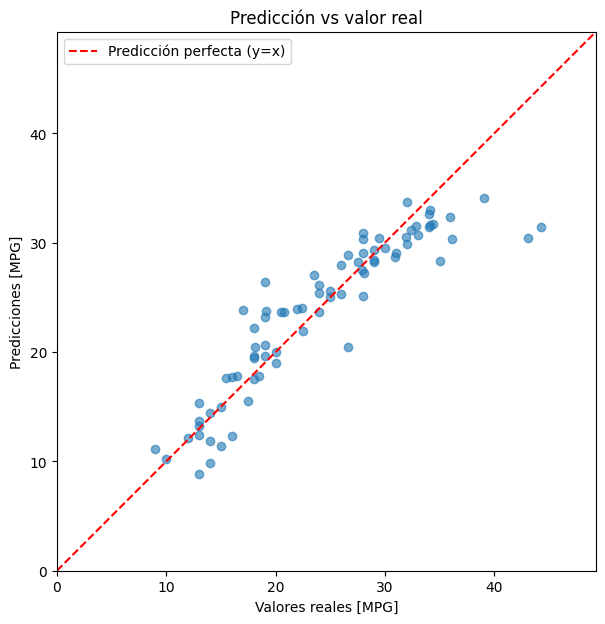

In [19]:
# Predecimos para TODO el test, no solo 10 ejemplos
test_predictions = model.predict(normed_test_data).flatten()

# Dibujamos el scatter: real (X) vs predicho (Y)
plt.figure(figsize=(7, 7))
plt.scatter(test_labels, test_predictions, alpha=0.6)
plt.xlabel('Valores reales [MPG]')
plt.ylabel('Predicciones [MPG]')
plt.axis('equal')                # mismas unidades en X e Y para que la diagonal sea de 45°
plt.axis('square')

# Forzamos que ambos ejes vayan desde 0 hasta el máximo de cualquiera de los dos
lims = [0, max(test_labels.max(), test_predictions.max()) + 5]
plt.xlim(lims)
plt.ylim(lims)

# Dibujamos la diagonal y=x para tener referencia visual del "acierto perfecto"
plt.plot(lims, lims, 'r--', label='Predicción perfecta (y=x)')
plt.legend()
plt.title('Predicción vs valor real')
plt.show()

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

### 📊 ¿Qué son los **residuos**?
El residuo de cada predicción es:

$$\text{residuo}_i = \hat{y}_i - y_i$$

Es decir, la diferencia entre lo que el modelo predijo y la verdad. Si el residuo es 0, acertó exactamente. Si es +3, predijo 3 MPG por encima.

**Lo que esperamos en un buen modelo de regresión**:
1. Distribución **centrada en 0** → no hay sesgo sistemático.
2. Forma aproximadamente **gaussiana (normal)** y simétrica → los errores son aleatorios, no sistemáticos.
3. **Sin colas largas** → no hay errores enormes recurrentes.

*Ejemplo*: si los residuos son `[1, -2, 0, 1, -1, 0]`, la media es 0 (buena señal) y todos son pequeños (buena señal).

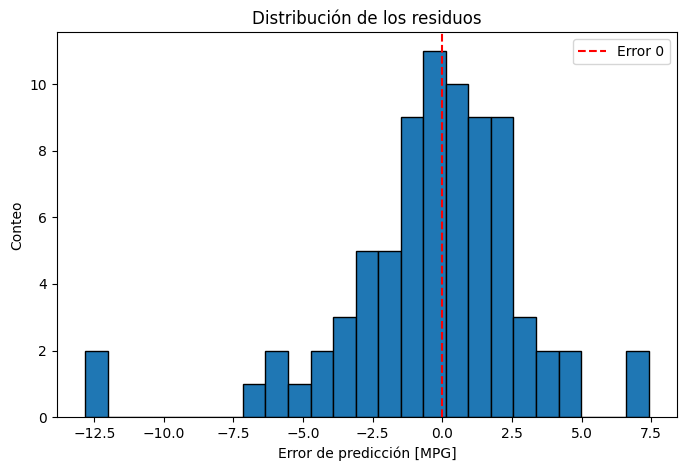

Media de los residuos: -0.350 MPG
Desv. estándar de los residuos: 3.347 MPG


In [20]:
# Calculamos los residuos: predicho - real
error = test_predictions - test_labels

# Dibujamos el histograma con 25 bins
plt.figure(figsize=(8, 5))
plt.hist(error, bins=25, edgecolor='black')
plt.xlabel('Error de predicción [MPG]')
plt.ylabel('Conteo')
plt.title('Distribución de los residuos')

# Línea vertical en 0 para ver de un vistazo si los errores están centrados
plt.axvline(0, color='red', linestyle='--', label='Error 0')
plt.legend()
plt.show()

# Imprimimos la media para confirmar si hay sesgo (si está cerca de 0, no lo hay)
print(f"Media de los residuos: {error.mean():.3f} MPG")
print(f"Desv. estándar de los residuos: {error.std():.3f} MPG")

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

### 💾 Cómo guardamos un modelo de keras
`model.save('nombre.keras')` guarda en un solo archivo:
- La arquitectura (capas y configuración).
- Los pesos entrenados.
- La configuración del compile (optimizer, loss, metrics).

Después podemos recuperarlo con `keras.models.load_model('nombre.keras')` sin tener que reentrenar.

In [21]:
# Guardamos el modelo en un archivo. La extensión .keras es el formato moderno recomendado
model.save('mpg_model.keras')
print("Modelo guardado como mpg_model.keras")

# Para volver a cargarlo en el futuro haríamos:
# modelo_recuperado = keras.models.load_model('mpg_model.keras')

Modelo guardado como mpg_model.keras


## Conclusion

### 📝 Resumen del notebook

Hemos construido un modelo de **regresión** con una red neuronal para predecir el consumo (MPG) de coches a partir de variables como cilindros, peso, potencia, etc.

**Pasos clave que hemos seguido**:

1. **Carga y limpieza de datos**: descargamos el Auto MPG dataset, eliminamos filas con NaN, transformamos la variable categórica `Origin` en columnas dummy con one-hot encoding y descartamos `Car name`.

2. **Train/test split** (80/20) con `sample` y `drop`, fijando semilla para reproducibilidad.

3. **Estandarización**: convertimos cada feature a media 0 y desviación 1 usando estadísticos del TRAIN (no del test, para evitar data leakage).

4. **Modelo**: red secuencial con dos capas ocultas Dense(64, relu) y una capa de salida Dense(1) sin activación. Compilada con `loss='mse'`, optimizer `RMSprop(0.001)` y métricas `mae`, `mse`.

5. **Entrenamiento**: 1000 epochs con `validation_split=0.2`, lo que nos permite vigilar sobreajuste comparando train_mae con val_mae.

6. **Evaluación en test**: obtuvimos un MAE en torno a unas pocas MPG. Ese número es el error medio que cabe esperar en datos nuevos.

7. **Diagnóstico**:
    - Scatter "predicho vs real" para ver si el modelo se alinea con la diagonal.
    - Histograma de residuos para comprobar que están centrados en 0 y son aproximadamente simétricos.

8. **Guardado** del modelo en formato `.keras` para reutilizarlo sin reentrenar.

**Posibles mejoras a explorar** (sin ser exhaustivos):
- Reducir epochs y añadir `EarlyStopping` para evitar sobreajuste.
- Probar arquitecturas más pequeñas (con tan pocos datos, redes grandes sobreajustan fácil).
- Aplicar regularización (`l2`, `Dropout`) si vemos curvas de val_loss subiendo.
- Comparar con modelos clásicos (Lasso, Ridge, Random Forest) — para datasets pequeños y tabulares, la red neuronal NO es necesariamente la mejor opción.